In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

In [5]:
data = np.array([
30,31,32,33,34,
35,36,37,38,39,
40,41,42,43,44,
45,46,47,48,49,
50,51,52,53,54,
55,56,57,58,59
])

In [6]:
data = data.reshape(-1,1)
print(data.shape)

(30, 1)


In [7]:
data

array([[30],
       [31],
       [32],
       [33],
       [34],
       [35],
       [36],
       [37],
       [38],
       [39],
       [40],
       [41],
       [42],
       [43],
       [44],
       [45],
       [46],
       [47],
       [48],
       [49],
       [50],
       [51],
       [52],
       [53],
       [54],
       [55],
       [56],
       [57],
       [58],
       [59]])

In [8]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [9]:
scaled_data

array([[0.        ],
       [0.03448276],
       [0.06896552],
       [0.10344828],
       [0.13793103],
       [0.17241379],
       [0.20689655],
       [0.24137931],
       [0.27586207],
       [0.31034483],
       [0.34482759],
       [0.37931034],
       [0.4137931 ],
       [0.44827586],
       [0.48275862],
       [0.51724138],
       [0.55172414],
       [0.5862069 ],
       [0.62068966],
       [0.65517241],
       [0.68965517],
       [0.72413793],
       [0.75862069],
       [0.79310345],
       [0.82758621],
       [0.86206897],
       [0.89655172],
       [0.93103448],
       [0.96551724],
       [1.        ]])

In [10]:
def create_dataset(dataset, time_step):
    X = []
    y = []

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])

    return np.array(X), np.array(y)

In [11]:
time_step = 5
X,y = create_dataset(scaled_data,time_step)

In [12]:
print(X.shape)

(25, 5, 1)


In [13]:
print(y.shape)

(25, 1)


In [14]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [15]:
lstm_model = Sequential()

lstm_model.add(LSTM(50,input_shape=(time_step,1)))

lstm_model.add(Dense(1))

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
lstm_model.compile(optimizer='adam',
                   loss='mse'
                   )

In [17]:
history_lstm = lstm_model.fit(X_train,y_train,epochs=100,batch_size=4,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.2631 - val_loss: 0.6797
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1888 - val_loss: 0.5129
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1346 - val_loss: 0.3503
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0788 - val_loss: 0.2057
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0391 - val_loss: 0.0848
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0088 - val_loss: 0.0162
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0041 - val_loss: 7.4927e-05
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0093 - val_loss: 7.8742e-04
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0078 - val_loss: 8.0249e-04
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0038 - val_loss: 0.0083
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0032 - val_loss: 0.0162
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0

In [18]:
lstm_predicction = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


In [21]:
actual = scaler.inverse_transform(y_test)

predicted = scaler.inverse_transform(lstm_predicction)

In [26]:
print(actual)

[[55.]
 [56.]
 [57.]
 [58.]
 [59.]]


In [24]:
print(predicted)

[[55.338406]
 [56.412018]
 [57.487057]
 [58.562695]
 [59.638077]]


In [27]:
last_sequence = np.array([55,56,57,58,59]).reshape(-1,1)

last_sequence = scaler.transform(last_sequence)

last_sequence = last_sequence.reshape(1,5,1)

next_value = lstm_model.predict(last_sequence)

next_value = scaler.inverse_transform(next_value)

print(next_value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
[[60.712395]]


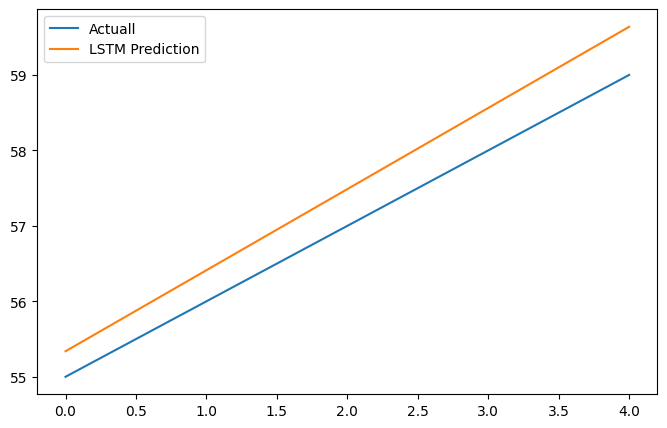

In [22]:
plt.figure(figsize=(8,5))
plt.plot(actual,label='Actuall')
plt.plot(predicted,label='LSTM Prediction')
plt.legend()
plt.show()

# Project 2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,GRU,Dense

In [4]:
data = np.array([
30,31,32,33,34,
35,36,37,38,39,
40,41,42,43,44,
45,46,47,48,49,
50,51,52,53,54,
55,56,57,58,59
])

In [5]:
data = data.reshape(-1,1)
print(data.shape)

(30, 1)


In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [7]:
def create_dataset(dataset,time_step):
    X = []
    y = []

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X),np.array(y)

In [8]:
time_step = 5 
X,y = create_dataset(scaled_data,time_step)

print(X.shape)
print(y.shape)

(25, 5, 1)
(25, 1)


In [9]:
train_size = int(len(X)*0.8)

X_train,X_test = X[:train_size],X[train_size:]
y_train,y_test = y[:train_size],y[train_size:]

In [10]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(time_step,1)))
lstm_model.add(Dense(1))

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

In [14]:
history_lstm = lstm_model.fit(X_train,y_train,epochs=100,batch_size=4,validation_data=(X_test,y_test), verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.3191 - val_loss: 0.8045
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2135 - val_loss: 0.5754
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1457 - val_loss: 0.3724
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0838 - val_loss: 0.2066
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0390 - val_loss: 0.0851
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 0.0203
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0051 - val_loss: 6.1740e-04
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0088 - val_loss: 2.7210e-04
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 4.5957e-04
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0048 - val_loss: 0.0057
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0030 - val_loss: 0.0131
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

In [15]:
lstm_prediction = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


In [16]:
actual = scaler.inverse_transform(y_test)
predicted = scaler.inverse_transform(lstm_prediction)

In [ ]:
last_sequence = np.array([55,56,57,58,59]).reshape(-1,1)

last_sequence = scaler.transform(last_sequence)

last_sequence = last_sequence.reshape(1,5,1)

next_value = lstm_model.predict(last_sequence)

next_value = scaler.inverse_transform(next_value)

print(next_value)

In [18]:
last_seq = np.array([55,56,57,58,59]).reshape(-1,1)
last_seq = scaler.transform(last_seq)
last_seq = last_seq.reshape(1,5,1)

next_val = lstm_model.predict(last_seq)
next_val = scaler.inverse_transform(next_val)
print(next_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[60.805397]]
